# Random Forest ek ensemble learning algorithm hai jo bahut saare Decision Trees ko alag-alag random bootstrap samples aur random features par train karta hai, aur phir un sabki predictions ko combine karke final prediction deta hai. Isse prediction zyada accurate, stable aur overfitting kam hoti hai.

# Simple Example

Maan lo tumhe decide karna hai ki student Pass hoga ya Fail.

Ek Decision Tree:

Tree 1 → Pass

Lekin Random Forest me 5 trees hain:

Tree 1 → Pass

Tree 2 → Pass

Tree 3 → Fail

Tree 4 → Pass

Tree 5 → Pass

Final Prediction:

Pass (Majority Vote)

# Random Forest ko "Random" kyu bolte hain?

Isme do jagah randomness hoti hai:

Random Data → Har tree alag bootstrap sample par train hota hai.

Random Features → Har split par sab features nahi, sirf kuch random features consider kiye jaate hain.

# Random Forest 3 things:

1. Row Sampling (Bootstrap Sampling) ✅

Original dataset:

1000 rows

Har Decision Tree ko random rows di jaati hain.

Example:

Tree 1 → Random 1000 rows

Tree 2 → Random 1000 rows

Tree 3 → Random 1000 rows

➡️ Isse har tree alag data par train hota hai.

2. Column Sampling (Feature Sampling) ✅

Maan lo dataset me 10 features hain.

Age

Salary

Gender

Height

Weight
City

Marks

Attendance

Experience

Income

Jab tree split karta hai, to saare 10 features nahi dekhta.

Wo randomly maan lo sirf 3 features dekhega.

Example:

Split 1 → Age, Marks, Salary

Split 2 → Height, City, Income

Split 3 → Weight, Experience, Age

➡️ Isse har tree aur bhi alag ban jata hai.

3. Combination (Final Prediction) ✅

Sab trees prediction dete hain.

Classification:

Tree1 → Cat

Tree2 → Dog

Tree3 → Dog

Tree4 → Dog

Final:

Dog (Majority Vote)

Regression:

Tree1 → ₹48 L

Tree2 → ₹50 L

Tree3 → ₹49 L

Final:

Average = ₹49 Lakh

# Ek line me yaad rakho

"Random Forest me Row Sampling (Bootstrap Sampling) + Column Sampling (Random Feature Selection) karke bahut saare Decision Trees banaye jaate hain, aur unki predictions ko combine (Majority Vote/Average) karke final prediction di jaati hai."

Yehi Random Forest ka complete core concept hai.

# Code

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification


In [ ]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [ ]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.026630,1.065466,0.954558,0.059123,1.048550,1
1,-1.284203,3.660346,-0.609823,-1.537492,2.922288,0
2,-1.939259,0.508837,0.768891,3.013796,-1.603096,1
3,0.852858,-1.229743,-1.701753,-0.652757,-0.137731,0
4,-2.569513,0.319991,0.180695,0.781258,-1.541538,1


In [ ]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)


In [ ]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols].copy() # Explicitly create a copy
  new_df['target'] = df['target']
  return new_df

In [ ]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)


In [ ]:
import random
df1 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_1486/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [ ]:
df2 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_1486/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [ ]:

df3 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_1486/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [ ]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col3', 'target'], dtype='object')
Index(['col1', 'col2', 'target'], dtype='object')
Index(['col3', 'col2', 'target'], dtype='object')


In [ ]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [ ]:

clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [ ]:

from sklearn.tree import plot_tree

[Text(0.4444444444444444, 0.9444444444444444, 'x[0] <= 0.64\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.2222222222222222, 0.8333333333333334, 'x[0] <= -1.017\ngini = 0.32\nsamples = 30\nvalue = [6, 24]'),
 Text(0.3333333333333333, 0.8888888888888888, 'True  '),
 Text(0.1111111111111111, 0.7222222222222222, 'gini = 0.0\nsamples = 14\nvalue = [0, 14]'),
 Text(0.3333333333333333, 0.7222222222222222, 'x[1] <= -0.064\ngini = 0.469\nsamples = 16\nvalue = [6, 10]'),
 Text(0.2222222222222222, 0.6111111111111112, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4444444444444444, 0.6111111111111112, 'x[0] <= -0.956\ngini = 0.444\nsamples = 15\nvalue = [5, 10]'),
 Text(0.3333333333333333, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5555555555555556, 0.5, 'x[1] <= 4.035\ngini = 0.408\nsamples = 14\nvalue = [4, 10]'),
 Text(0.4444444444444444, 0.3888888888888889, 'x[1] <= 0.686\ngini = 0.355\nsamples = 13\nvalue = [3, 10]'),
 Text(0.2222222222222222, 0.2777777777777778, '

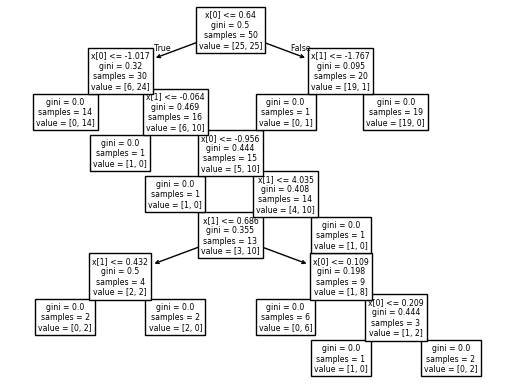

In [ ]:

plot_tree(clf2)

[Text(0.1875, 0.9666666666666667, 'x[0] <= 0.798\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.125, 0.9, 'x[0] <= -1.988\ngini = 0.424\nsamples = 36\nvalue = [25, 11]'),
 Text(0.15625, 0.9333333333333333, 'True  '),
 Text(0.0625, 0.8333333333333334, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.1875, 0.8333333333333334, 'x[1] <= -1.843\ngini = 0.389\nsamples = 34\nvalue = [25, 9]'),
 Text(0.125, 0.7666666666666667, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.25, 0.7666666666666667, 'x[1] <= 0.082\ngini = 0.342\nsamples = 32\nvalue = [25, 7]'),
 Text(0.1875, 0.7, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.3125, 0.7, 'x[1] <= 0.399\ngini = 0.413\nsamples = 24\nvalue = [17, 7]'),
 Text(0.25, 0.6333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.375, 0.6333333333333333, 'x[0] <= -1.441\ngini = 0.386\nsamples = 23\nvalue = [17, 6]'),
 Text(0.3125, 0.5666666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4375, 0.566666666666666

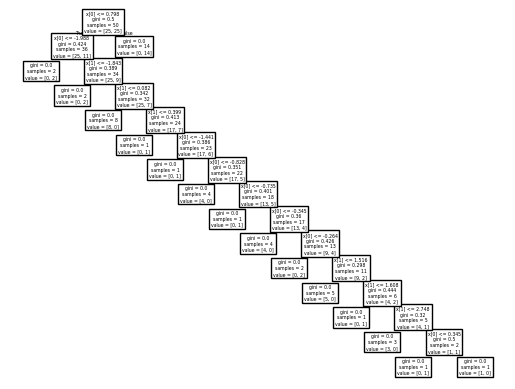

In [ ]:
plot_tree(clf3)

In [ ]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [ ]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [ ]:


clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [ ]:

df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
39,0.227806,0.478532,-0.655902,-2.102200,1.535091,0
29,1.590413,0.921347,-0.537804,-2.078869,1.173349,0
99,-1.853970,-0.200960,0.066682,-3.675895,1.304186,1
26,1.602075,0.785098,-0.980393,-2.796552,2.230627,0
87,-0.041864,2.380488,-0.247426,-4.765897,-0.338162,1
79,-0.450667,1.552383,-0.021396,-0.244782,0.384437,1
5,1.695470,2.025229,0.073715,-0.146925,0.259715,0
58,0.243122,-0.869821,-1.876112,0.049592,-0.435245,0
20,-3.535619,0.294675,-2.109349,-2.570519,-0.460694,1
99,-1.853970,-0.200960,0.066682,-3.675895,1.304186,1


# How Random Forest Performs So Well




Random Forest achha perform karta hai kyunki ye ek Decision Tree par bharosa nahi karta. Ye bahut saare Decision Trees ko alag-alag random rows (bootstrap sampling) aur random columns (feature sampling) par train karta hai. Har tree alag prediction deta hai, aur final prediction majority voting (classification) ya averaging (regression) se li jaati hai. Is wajah se kisi ek tree ki galti ka asar kam ho jata hai, overfitting reduce hoti hai, variance kam hoti hai aur model zyada stable aur accurate ban jata hai.

# Code

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt


In [ ]:
np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
X.shape

(500, 2)

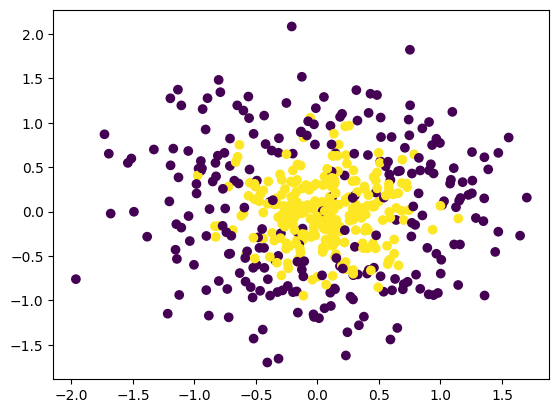

In [ ]:
plt.scatter(X[:,0],X[:,1],c=y)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

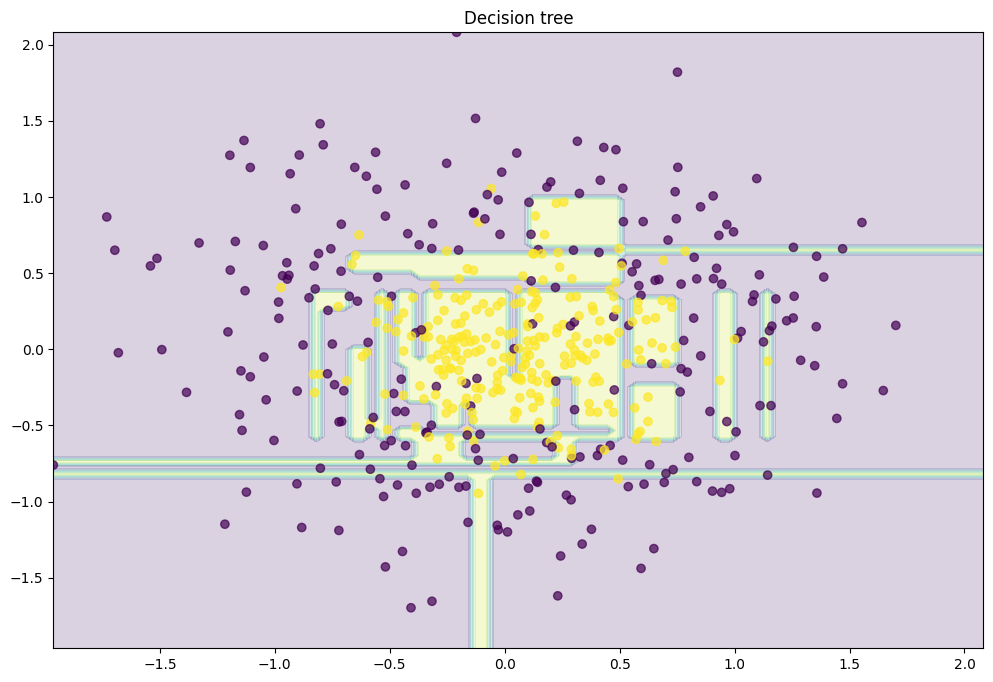

In [ ]:
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Decision tree")
plt.show()


In [ ]:


from sklearn.ensemble import RandomForestClassifier

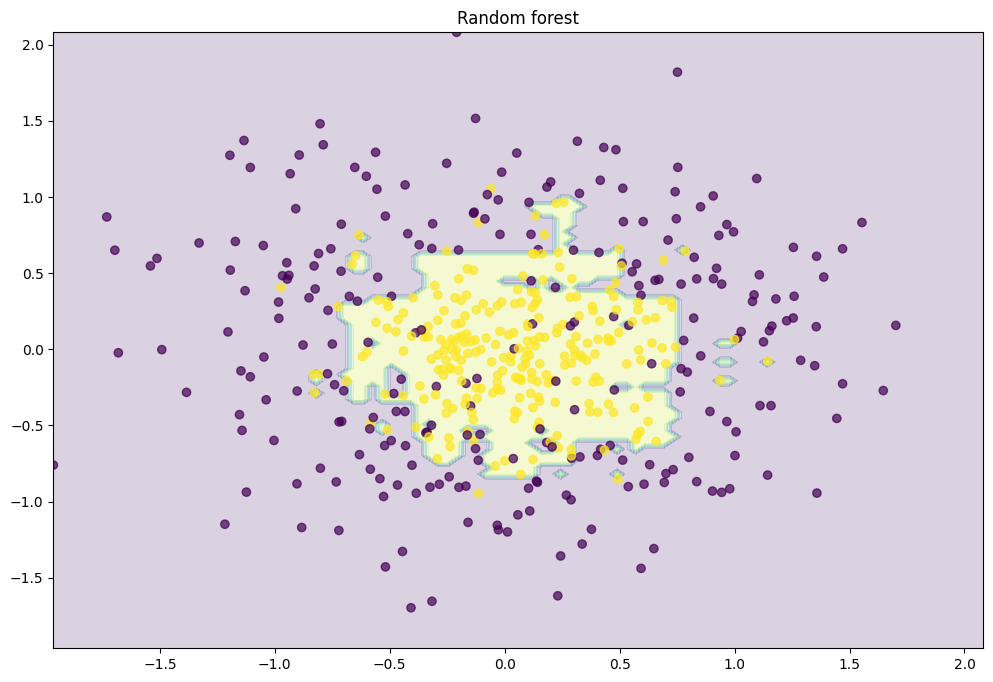

In [ ]:
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Random forest")
plt.show()



In [ ]:

n_train = 150
n_test = 1000
noise = 0.1

# Generate data
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)

def generate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = np.exp(-X ** 2) + 1.5 * np.exp(-(X - 2) ** 2)\
        + np.random.normal(0.0, noise, n_samples)
    X = X.reshape((n_samples, 1))

    return X, y

X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise)

(-5.0, 5.0)

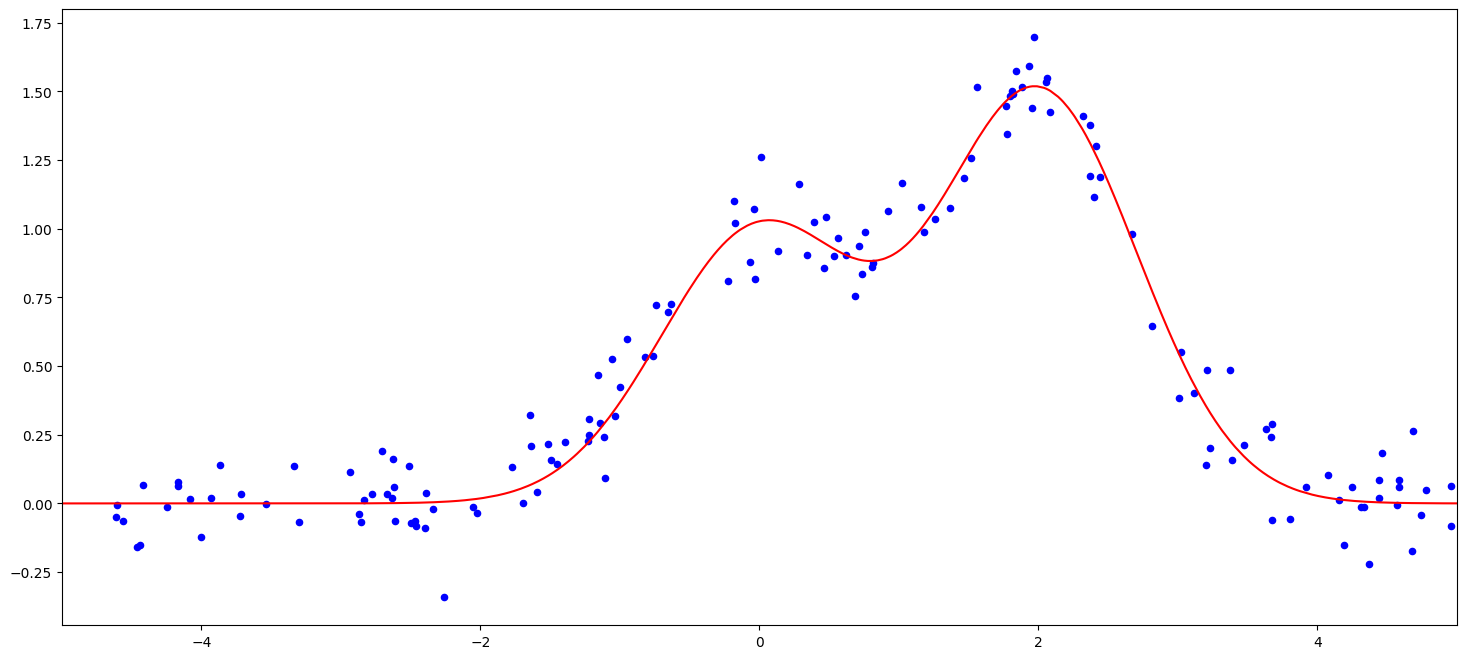

In [ ]:
plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.xlim([-5, 5])


(-5.0, 5.0)

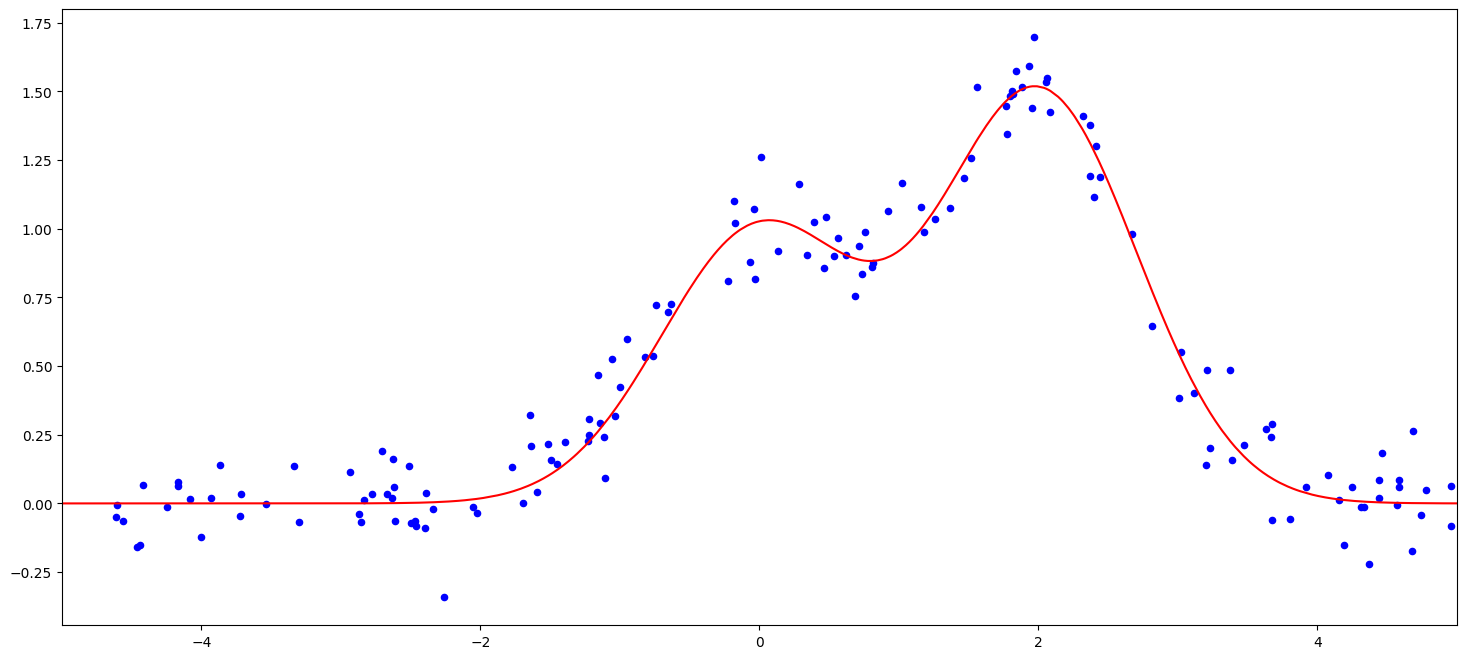

In [ ]:
plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.xlim([-5, 5])


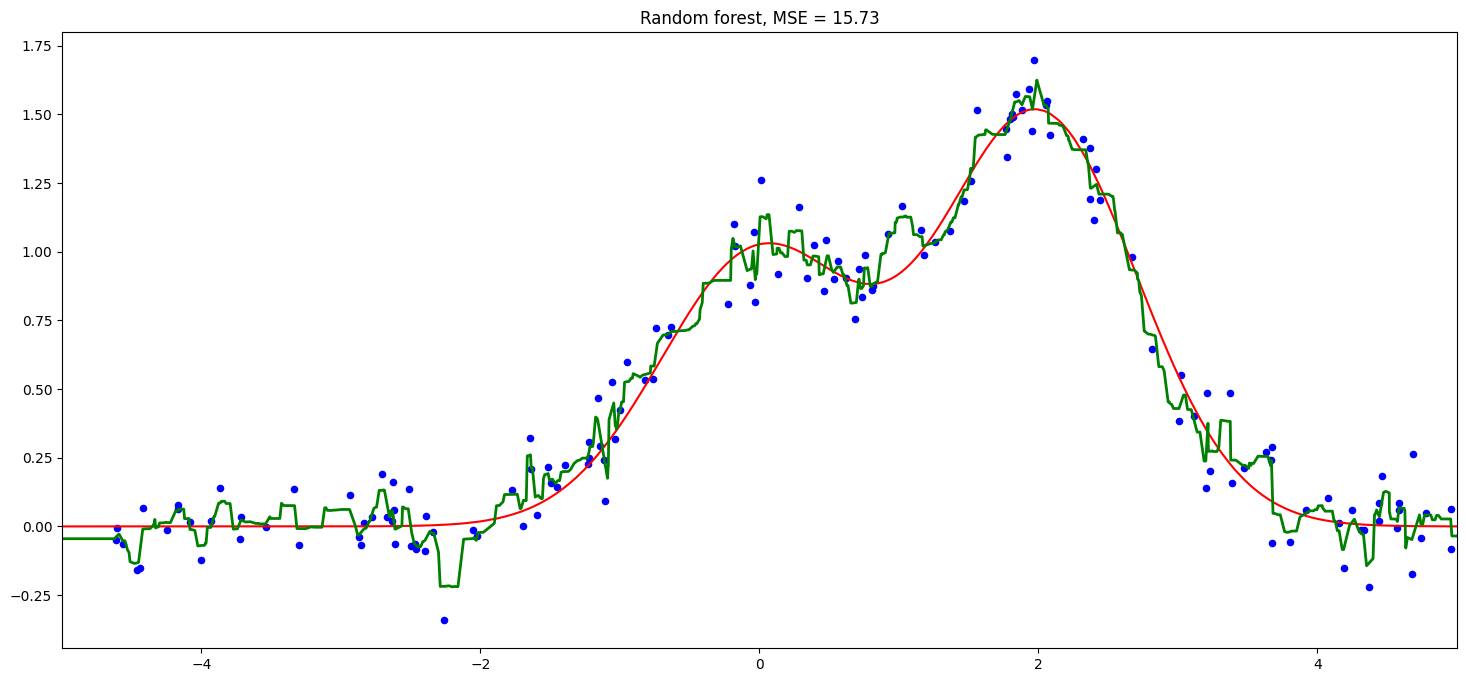

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=1000).fit(X_train, y_train)
rf_predict = rfr.predict(X_test)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, rf_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Random forest, MSE = %.2f" % np.sum((y_test - rf_predict) ** 2));




# Bagging Vs Random Forest

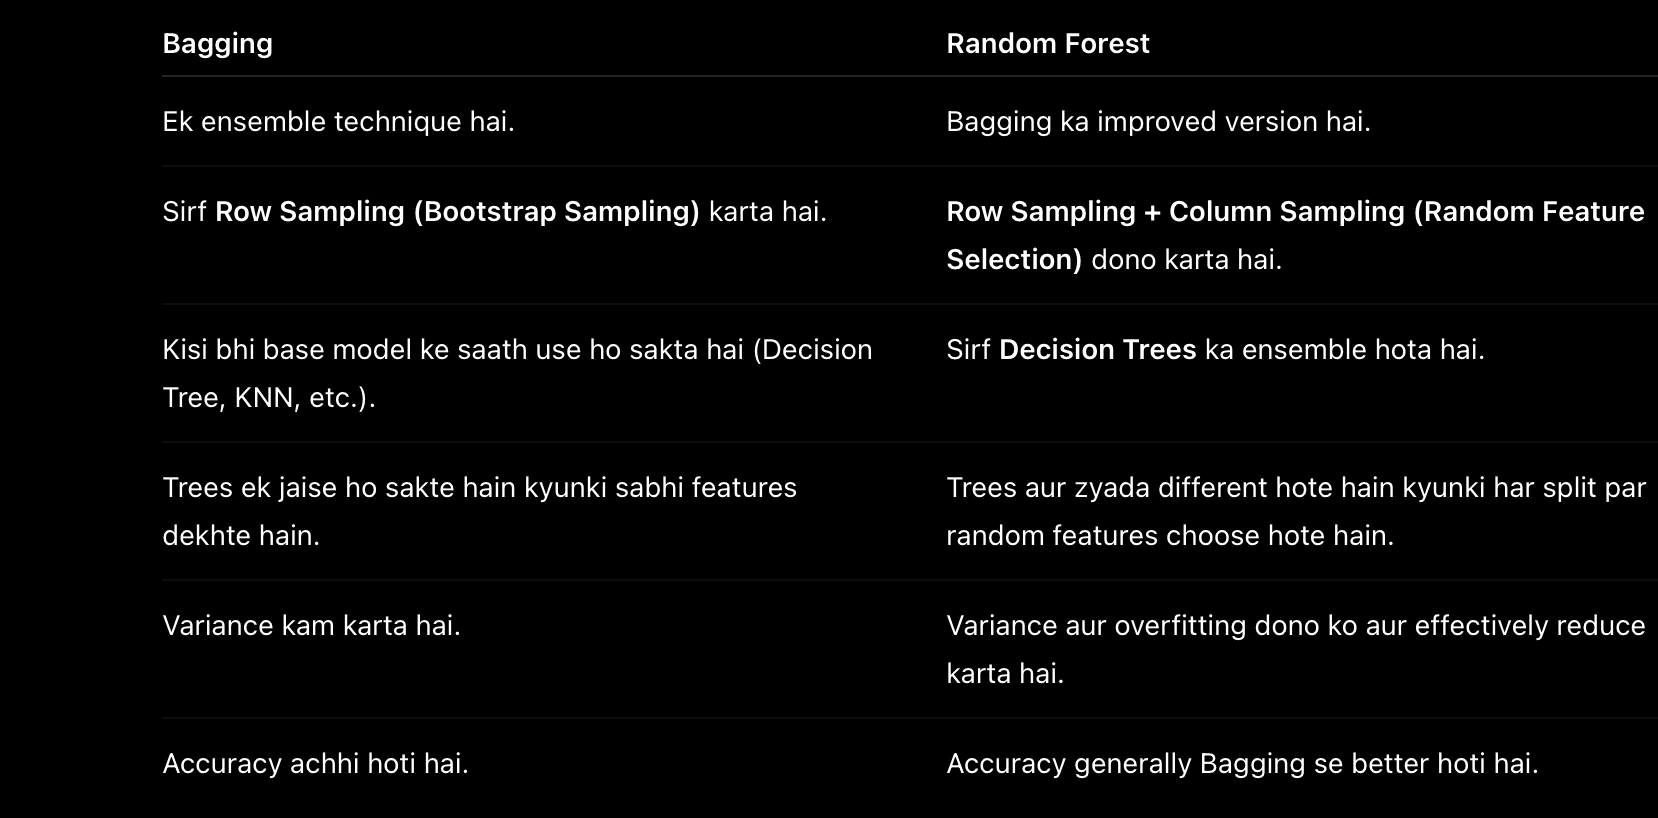

# Sabse important difference

Bagging:

Random Rows
        ↓
Decision Trees
        ↓
Majority Vote / Average

Random Forest:

Random Rows + Random Columns
             ↓
      Decision Trees
             ↓
    Majority Vote / Average

# Code

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [ ]:

X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)


In [ ]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()


(100, 6)


,col1,col2,col3,col4,col5,target
0,0.994618,-2.955802,-0.411398,-1.264043,-0.406864,1
1,0.228420,-1.491013,1.890480,-0.917665,1.920842,1
2,-2.159411,-1.647563,-2.525786,-3.922646,1.456224,0
3,2.382876,-2.318275,-0.814980,-1.872522,1.569654,1
4,0.061373,0.206547,2.793017,-0.762940,1.191836,1


In [ ]:
bag = BaggingClassifier(max_features=2)

In [ ]:

bag.fit(df.iloc[:,:5],df.iloc[:,-1])

BaggingClassifier(max_features=2)

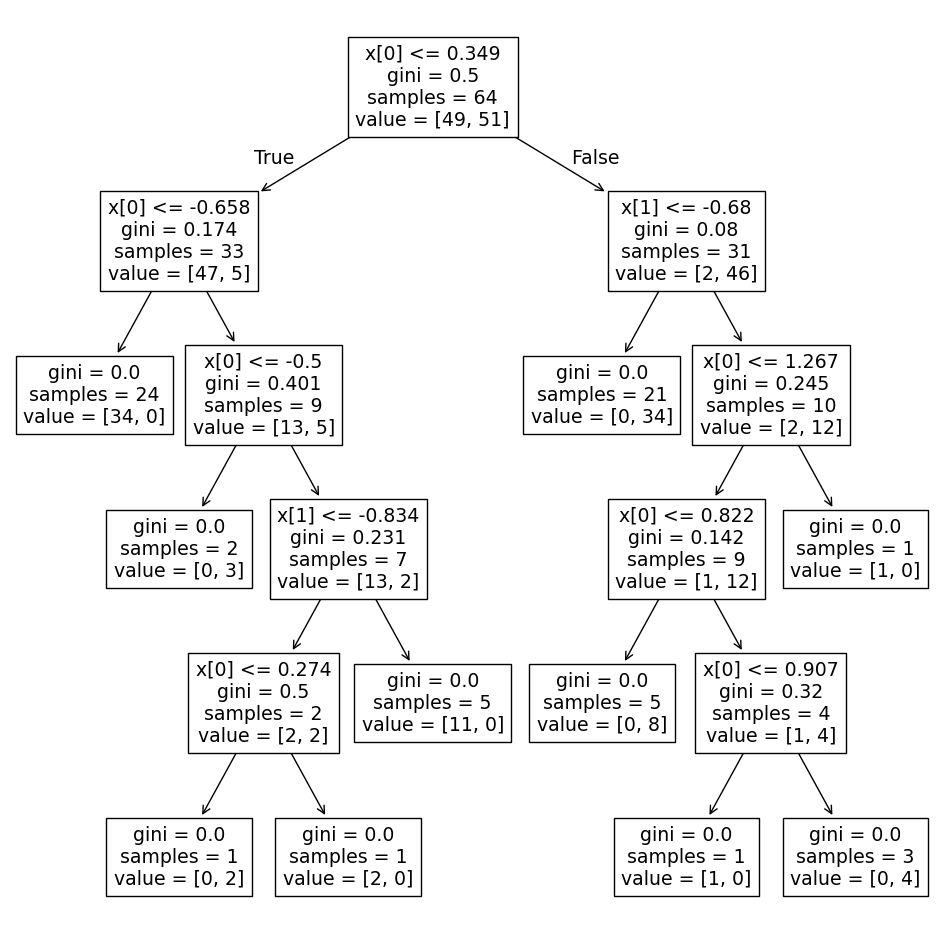

In [ ]:

plt.figure(figsize=(12,12))
plot_tree(bag.estimators_[0])
plt.show()

In [ ]:
rf = RandomForestClassifier(max_features=2)


In [ ]:

rf.fit(df.iloc[:,:5],df.iloc[:,-1])

RandomForestClassifier(max_features=2)

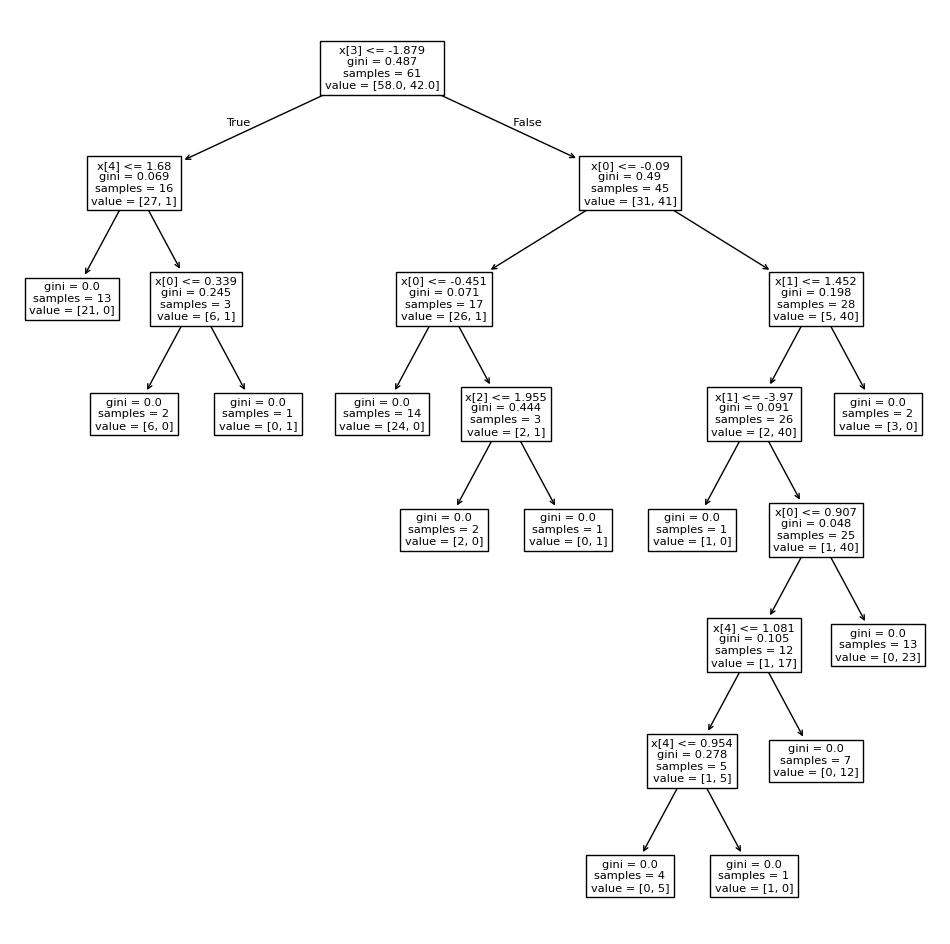

In [ ]:

plt.figure(figsize=(12,12))
plot_tree(rf.estimators_[4])
plt.show()


# Kya bagging ko decison tree leke banau to wo random forest hai ?

Agar tum Bagging me Decision Tree use karte ho, to wo automatically Random Forest nahi ban jata.

Reason

Bagging + Decision Tree

✅ Random Rows (Bootstrap Sampling)

❌ Saare features (columns) har split par available hote hain.

Random Rows
      ↓
Decision Tree (All Features)

# Random Forest

✅ Random Rows (Bootstrap Sampling)

✅ Random Columns (Feature Sampling) har split par.

Random Rows + Random Columns
            ↓
      Decision Tree

# Example

Dataset me 10 features hain.

Bagging + Decision Tree

Har tree split karte waqt saare 10 features dekh sakta hai.

Age

Salary

Marks

Height

Weight
...

(All 10)

Random Forest

Har split par sirf random 3–4 features dekhega.

Split 1 → Age, Marks, Salary

Split 2 → Height, Weight, City

Split 3 → Marks, Income, Experience

Isi wajah se har tree aur bhi alag banta hai.


# Sirf Bagging me Decision Tree use karne se Random Forest nahi banta, kyunki Bagging sirf bootstrap row sampling karta hai aur har Decision Tree split ke time sabhi features (columns) ko consider karta hai. Random Forest, Bagging ka hi advanced version hai jo bootstrap row sampling ke saath-saath har split par random feature (column) selection bhi karta hai. Isi random feature selection ki wajah se har tree aur zyada diverse banta hai, overfitting aur variance aur kam hoti hai, aur model ki accuracy improve hoti hai.



# Random Forest Hyperparameters

Socho tum ek forest bana rahe ho.

Tum decide karoge:

Kitne trees honge?

Har tree kitna bada hoga?

Har tree kitni information dekhega?

Yehi hyperparameters hain.

# 1. n_estimators
Ye kya hai?

Forest me kitne Decision Trees honge.

Example:

n_estimators = 5

Matlab

🌳 🌳 🌳 🌳 🌳

5 Trees.

Agar

n_estimators = 100

To

🌳 🌳 🌳 🌳 🌳 🌳 🌳 🌳 🌳 🌳 ...

100 Trees

Effect

Zyada trees → Better prediction
Lekin training slow hogi

Yaad rakho:

n_estimators = Number of Trees

#2. max_depth
Ye kya hai?

Ek tree kitna lamba grow karega.

Example

Depth = 2

        Root
       /    \
     Yes    No

Bas 2 levels.

Agar

Depth = 10

Tree bahut bada ho jayega.

Effect

Chhoti depth → Underfitting

Bahut badi depth → Overfitting

Yaad rakho:

max_depth = Tree ki maximum height

# 3. max_features ⭐ (Most Important)

Random Forest ki jaan.

Suppose tumhare dataset me

Age

Salary

Height

Weight

Marks

Attendance

City

Gender

Total

8 Features

Ab split karte waqt

Decision Tree normally

Saare 8 Features dekhega.

Lekin Random Forest me

max_features = 3

Matlab

Har split par sirf random 3 features dekhega.

Example

Split 1

Age

Marks

Salary

Split 2

Weight

City

Gender

Split 3

Height

Salary

Attendance

Isliye har tree alag banta hai.

Yaad rakho:

max_features = Har split par kitne random columns dekhne hain.

# 4. min_samples_split

Ye batata hai

Node ko split karne ke liye minimum kitne samples hone chahiye.

Example

Node me

100 Samples

Split ho sakta hai.

Lekin

Sirf 2 Samples

Agar

min_samples_split = 5

To

2 samples wale node ko split nahi karega.

Effect

Bina wajah bahut chhote nodes nahi banenge.

# 5. min_samples_leaf

Leaf me minimum kitne samples hone chahiye.

Example

Agar

min_samples_leaf = 3

To leaf me

1 Sample

Nahi ho sakta.

Kam se kam

3 Samples

Hone hi chahiye.

Isse overfitting kam hoti hai.

 #6. bootstrap

Ye batata hai

Bootstrap Sampling use karni hai ya nahi.

bootstrap = True

Random rows use hongi.

bootstrap = False

Original data use hoga.

Random Forest me normally

True

Hi rehta hai.

# 7. criterion

Ye batata hai

Split kis basis par hoga.

Classification

Gini

Entropy

Regression

Squared Error

Model best split choose karta hai.

# 8. random_state

Ye sirf randomness ko fix karta hai.

Example

Aaj model chalaya

Accuracy = 95%

Kal chalaya

94%

Agar

random_state = 42

To har baar same random sampling hogi aur same result milega.

```
| Gini                                          | Entropy                                |
| --------------------------------------------- | -------------------------------------- |
| Faster calculate hota hai                     | Thoda slow hota hai                    |
| Simple impurity measure                       | Information/uncertainty measure        |
| Default in many Decision Tree implementations | Information Gain ke saath use hota hai |
```


# Code

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

In [ ]:
df.head()

,col1,col2,col3,col4,col5,target
0,0.994618,-2.955802,-0.411398,-1.264043,-0.406864,1
1,0.228420,-1.491013,1.890480,-0.917665,1.920842,1
2,-2.159411,-1.647563,-2.525786,-3.922646,1.456224,0
3,2.382876,-2.318275,-0.814980,-1.872522,1.569654,1
4,0.061373,0.206547,2.793017,-0.762940,1.191836,1


In [ ]:
df.shape

(100, 6)

In [ ]:
X = df.iloc[:,0:-1]
y = df.iloc[:,-1]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(80, 5)
(20, 5)


In [ ]:
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
svc = SVC()
lr = LogisticRegression()

In [ ]:
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

In [ ]:
gb.fit(X_train,y_train)
y_pred = gb.predict(X_test)
accuracy_score(y_test,y_pred)

0.9

In [ ]:
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

In [ ]:
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_test,y_pred)

0.95

In [ ]:
rf = RandomForestClassifier(max_samples=0.75,random_state=42)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

In [ ]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(RandomForestClassifier(max_samples=0.75),X,y,cv=10,scoring='accuracy'))

np.float64(0.9)

# GridSearchCV

In [ ]:
# Number of trees in random forest
n_estimators = [20,60,100,120]

# Number of features to consider at every split
max_features = [0.2,0.6,1.0]

# Maximum number of levels in tree
max_depth = [2,8,None]

# Number of samples
max_samples = [0.5,0.75,1.0]

# 108 diff random forest train

In [ ]:
param_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
              'max_samples':max_samples
             }
print(param_grid)

{'n_estimators': [20, 60, 100, 120], 'max_features': [0.2, 0.6, 1.0], 'max_depth': [2, 8, None], 'max_samples': [0.5, 0.75, 1.0]}


In [ ]:
rf = RandomForestClassifier()

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_grid = GridSearchCV(estimator = rf,
                       param_grid = param_grid,
                       cv = 5,
                       verbose=2,
                       n_jobs = -1)

In [ ]:
rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [2, 8, None],
                         'max_features': [0.2, 0.6, 1.0],
                         'max_samples': [0.5, 0.75, 1.0],
                         'n_estimators': [20, 60, 100, 120]},
             verbose=2)

In [ ]:
rf_grid.best_params_

{'max_depth': 8, 'max_features': 0.6, 'max_samples': 1.0, 'n_estimators': 20}

In [ ]:
rf_grid.best_score_

np.float64(0.9375)

# RandomSearchCV

RandomizedSearchCV ek hyperparameter tuning technique hai jo sabhi possible combinations ko check karne ki jagah randomly kuch combinations ko try karti hai aur unme se best hyperparameters choose karti hai. Isse time bachta hai aur achhe results mil jate hain.

In [ ]:
# Number of trees in random forest
n_estimators = [20,60,100,120]

# Number of features to consider at every split
max_features = [0.2,0.6,1.0]

# Maximum number of levels in tree
max_depth = [2,8,None]

# Number of samples
max_samples = [0.5,0.75,1.0]

# Bootstrap samples
bootstrap = [True,False]

# Minimum number of samples required to split a node
min_samples_split = [2, 5]

# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2]

In [ ]:
param_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
              'max_samples':max_samples,
              'bootstrap':bootstrap,
              'min_samples_split':min_samples_split,
              'min_samples_leaf':min_samples_leaf
             }
print(param_grid)

{'n_estimators': [20, 60, 100, 120], 'max_features': [0.2, 0.6, 1.0], 'max_depth': [2, 8, None], 'max_samples': [0.5, 0.75, 1.0], 'bootstrap': [True, False], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_grid = RandomizedSearchCV(estimator = rf,
                       param_distributions = param_grid,
                       cv = 5,
                       verbose=2,
                       n_jobs = -1)

In [ ]:
rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py", line 431, in fit
    raise ValueError(
ValueError:

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [2, 8, None],
                                        'max_features': [0.2, 0.6, 1.0],
                                        'max_samples': [0.5, 0.75, 1.0],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [20, 60, 100, 120]},
                   verbose=2)

In [ ]:
rf_grid.best_params_

{'n_estimators': 120,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_samples': 0.5,
 'max_features': 1.0,
 'max_depth': None,
 'bootstrap': True}

In [ ]:
rf_grid.best_score_

np.float64(0.925)

# OOB (Out-of-Bag) Evaluation

Random Forest me har Decision Tree bootstrap sampling se train hota hai.

Bootstrap sampling me kuch rows select hoti hain, aur kuch select nahi hoti.

Jo rows select nahi hoti, unhe Out-of-Bag (OOB) samples kehte hain.

# Example

Original dataset:

1 2 3 4 5 6 7 8 9 10

Tree 1 ke liye bootstrap sample:

1 2 2 4 5 6 6 8 9 9

Dhyan do:

3, 7, 10

Ye rows use hi nahi hui training me.

Ye hi OOB samples hain.

# OOB Evaluation ka concept

Ab Tree 1 ko test kis par karenge?

👉 Unhi rows par jo usne training me nahi dekhi.

Training → 1 2 2 4 5 6 6 8 9 9

Testing (OOB) → 3 7 10

Har tree apne OOB samples par test hota hai.

Phir sab trees ke OOB predictions ko combine karke model ki accuracy nikalte hain.

# Iski zarurat kyu?

Normally hume model evaluate karne ke liye alag test set banana padta hai.

Lekin Random Forest me bootstrap sampling ki wajah se har tree ke paas pehle se hi kuch unseen data hota hai.

Isliye alag test set ki zarurat nahi padti.

# Out-of-Bag (OOB) Evaluation Random Forest ki ek evaluation technique hai jisme bootstrap sampling ke dauran jo samples kisi Decision Tree ki training me use nahi hote, unhe us tree ke test data ke roop me use kiya jata hai. Har tree apne OOB samples par prediction karta hai, aur sabhi OOB predictions ko combine karke model ki performance measure ki jaati hai. Isse alag validation set ki zarurat nahi padti aur model ki generalization performance ka achha estimate milta hai.

# Code OOB_Score

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [ ]:

df.head()

,col1,col2,col3,col4,col5,target
0,0.994618,-2.955802,-0.411398,-1.264043,-0.406864,1
1,0.228420,-1.491013,1.890480,-0.917665,1.920842,1
2,-2.159411,-1.647563,-2.525786,-3.922646,1.456224,0
3,2.382876,-2.318275,-0.814980,-1.872522,1.569654,1
4,0.061373,0.206547,2.793017,-0.762940,1.191836,1


In [ ]:
X = df.iloc[:,0:-1]
y = df.iloc[:,-1]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
rf = RandomForestClassifier(oob_score=True)

In [ ]:
rf.fit(X_train,y_train)

RandomForestClassifier(oob_score=True)

In [ ]:
rf.oob_score_

0.925

In [ ]:
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.95

# Feature Importance using Random Forest and Decision Trees

Feature Importance batati hai ki kaunsa feature (column) prediction me sabse zyada contribute kar raha hai.

Example:

```
| Feature       | House Price |
| ------------- | ----------- |
| Area          | ✅           |
| Bedrooms      | ✅           |
| Age           | ✅           |
| Color of Door | ❌           |

```

Yaha Area aur Bedrooms important hain, jabki Door Color ka koi khaas effect nahi hai.

# Decision Tree me Feature Importance

Decision Tree data ko baar-baar split karta hai.

Har split se data aur pure (clean) ho jata hai.

Jo feature impurity ko sabse zyada reduce karta hai, uski importance zyada hoti hai.

Example:

          Area
        /      \
      Age      Bedrooms
     /  \        /   \

Suppose

Area split → Error 60 se 20 ho gaya

Age split → Error 20 se 12


Bedrooms split → Error 20 se 18

Area ne sabse zyada improvement di.

Isliye

Area > Age > Bedrooms

Importance bhi isi order me hogi.

# Decision Tree Importance ka Formula

Har split pe calculate hota hai

Importance

=

Impurity Before Split
-

Weighted Impurity After Split

# Random Forest me Feature Importance

Random Forest me ek tree nahi hota.

Bahut saare Decision Trees hote hain.

Tree1

Tree2

Tree3

Tree4

...

Tree100

Har tree apni importance calculate karta hai.

Phir sabka average nikal diya jata hai.

Example

Tree1

Area = 0.6

Age = 0.2

Bedroom = 0.2

Tree2

Area = 0.5

Age = 0.3

Bedroom = 0.2

Tree3

Area = 0.4

Age = 0.4

Bedroom = 0.2

Average

Area = (0.6+0.5+0.4)/3 = 0.50

Age = (0.2+0.3+0.4)/3 = 0.30

Bedroom = 0.20

Ye hi final Random Forest Feature Importance hoti hai.

# Random Forest zyada reliable kyun hai?

Decision Tree

Sirf ek tree

Agar tree galat ban gaya to importance bhi galat ho sakti hai.

Random Forest

100-500 trees

↓

Average

↓

Stable Result

Isliye Random Forest ki importance zyada trustworthy hoti hai.

# Decision Tree vs Random Forest Feature Importance

```
| Decision Tree               | Random Forest                           |
| --------------------------- | --------------------------------------- |
| Ek tree ki importance       | Bahut saare trees ki average importance |
| Unstable ho sakti hai       | Zyada stable aur reliable               |
| Overfitting ka effect zyada | Overfitting kam hoti hai                |
| Fast                        | Thoda slower                            |
| Less accurate               | More accurate                           |
```

# Decision Tree: "Jo feature split ke time impurity ko sabse zyada reduce kare, wahi sabse important."

# Random Forest: "Har Decision Tree apni feature importance nikalta hai, aur sab trees ki average importance final feature importance hoti hai."


# Feature Selection

Feature Selection ek process hai jisme hum dataset ke sirf important features (columns) ko select karte hain aur unnecessary ya irrelevant features ko hata dete hain, taaki model fast, simple aur zyada accurate ban sake.

 # Why do we need Feature Selection?
Removes unnecessary features.

Reduces overfitting.

Improves model accuracy.

Makes training faster.

Makes the model easier to understand.



# How is Feature Importance Calculated?

Feature Importance batati hai ki **har feature prediction me kitna contribution de raha hai**. Iska calculation model par depend karta hai. Decision Tree aur Random Forest me ye **impurity reduction** ke basis par calculate hoti hai.

## Step 1: Data ko Split Karna

Decision Tree har node par best feature choose karta hai jo data ko sabse achhe tarike se split kare.

Example:

```
          Area
         /    \
      Age    Bedrooms
```

Yahan **Area** pehla split hai kyunki isne data ko sabse achhe se separate kiya.

---

## Step 2: Impurity Reduction Calculate Karna

Har split se pehle aur baad ki impurity compare ki jati hai.

**Formula:**

```
Feature Importance (Split Gain)
=
Impurity Before Split
−
Weighted Impurity After Split
```

* Agar impurity me bada reduction aata hai, to feature zyada important hai.
* Agar reduction bahut kam hai, to feature ki importance bhi kam hogi.

---

## Step 3: Har Feature ke Gains ko Add Karna

Agar ek feature multiple baar tree me split ke liye use hua hai, to uske saare impurity reductions ko add kar diya jata hai.

Example:

| Feature  | Total Gain |
| -------- | ---------: |
| Area     |         50 |
| Age      |         20 |
| Bedrooms |         30 |

---

## Step 4: Normalize Karna

Sab gains ka sum nikal kar har feature ko divide kar dete hain, taaki total importance **1 (100%)** ho jaye.

Example:

```
Total Gain = 50 + 20 + 30 = 100

Area       = 50 / 100 = 0.50
Age        = 20 / 100 = 0.20
Bedrooms   = 30 / 100 = 0.30
```

Final Feature Importance:

| Feature  | Importance |
| -------- | ---------: |
| Area     | 0.50 (50%) |
| Bedrooms | 0.30 (30%) |
| Age      | 0.20 (20%) |

---

## Random Forest me Feature Importance

Random Forest me sirf ek tree nahi hota, balki bahut saare Decision Trees hote hain.

Har tree apni feature importance calculate karta hai, aur final importance sabhi trees ki **average** hoti hai.

Example:

```
Tree 1:
Area = 0.60
Age = 0.20
Bedrooms = 0.20

Tree 2:
Area = 0.50
Age = 0.30
Bedrooms = 0.20

Tree 3:
Area = 0.40
Age = 0.40
Bedrooms = 0.20
```

Average:

```
Area = (0.60 + 0.50 + 0.40) / 3 = 0.50

Age = (0.20 + 0.30 + 0.40) / 3 = 0.30

Bedrooms = (0.20 + 0.20 + 0.20) / 3 = 0.20
```

Yahi Random Forest ki final Feature Importance hoti hai.

---

## Easy Trick to Remember 🎯

* **Decision Tree:** Har split par dekhta hai ki kis feature ne impurity ko sabse zyada reduce kiya.
* **Random Forest:** Har tree ki feature importance nikalta hai aur un sabki **average** ko final feature importance maan leta hai.


# Code

In [1]:
import pandas as pd
import seaborn as sns

In [16]:
import pandas as pd
from sklearn.datasets import fetch_openml

# Load the MNIST dataset using sklearn.datasets.fetch_openml
# This is a more robust way to get the MNIST data directly
print("Fetching MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=True, parser='auto')

# Prepare the DataFrame 'df' as expected by subsequent cells
# The original 'train.csv' for MNIST typically has the label as the first column, followed by pixel values.
# fetch_openml provides data (X_mnist) and target (y_mnist) separately.
# So, we concatenate them with 'label' as the first column.
X_mnist = mnist.data
y_mnist = mnist.target

df = pd.concat([y_mnist.rename('label'), X_mnist], axis=1)

print("MNIST dataset loaded successfully into DataFrame 'df'.")
print(df.head())

Fetching MNIST dataset...
MNIST dataset loaded successfully into DataFrame 'df'.
  label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0     5       0       0       0       0       0       0       0       0   
1     0       0       0       0       0       0       0       0       0   
2     4       0       0       0       0       0       0       0       0   
3     1       0       0       0       0       0       0       0       0   
4     9       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   


In [22]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

<Axes: >

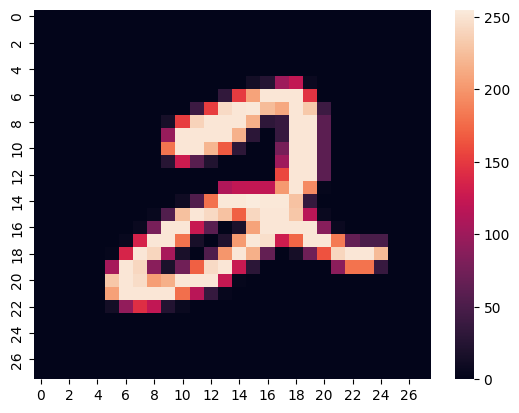

In [23]:
sns.heatmap(X.iloc[5].values.reshape(28,28))

In [24]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X,y)

RandomForestClassifier()

In [25]:
rf.feature_importances_

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 5.66852222e-07, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 6.72987131e-07, 1.65719134e-06, 0.00000000e+00,
       1.43435347e-06, 3.70751844e-06, 4.86072276e-06, 5.31030128e-06,
       3.23851099e-06, 9.22643657e-07, 2.85077713e-06, 3.06288686e-06,
       2.94023867e-06, 2.54114522e-06, 8.73432386e-07, 1.23060320e-06,
       7.57143159e-07, 0.00000000e+00, 6.26486229e-07, 7.66013930e-07,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

In [26]:
rf.feature_importances_.shape

(784,)

<Axes: >

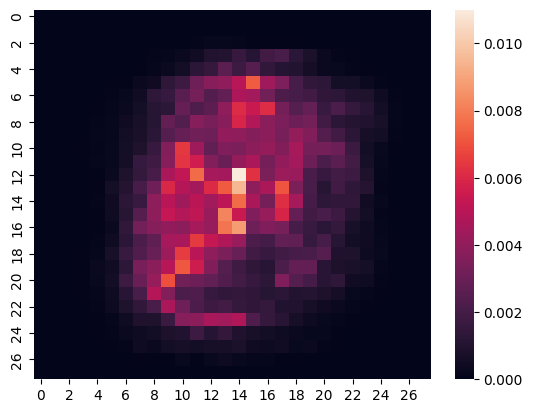

In [27]:

sns.heatmap(rf.feature_importances_.reshape(28,28))

# how-feature-importance-is-calculated. Code

In [11]:
from sklearn.datasets import make_classification

In [12]:
from sklearn.tree import DecisionTreeClassifier

In [13]:
X,y = make_classification(n_samples=5, n_classes=2,
                               n_features=2, n_informative=2, n_redundant=0,
                               random_state=0)


In [14]:
clf = DecisionTreeClassifier()

In [15]:

clf.fit(X,y)

DecisionTreeClassifier()

[Text(0.4, 0.8333333333333334, 'x[0] <= -0.875\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[0] <= 1.01\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

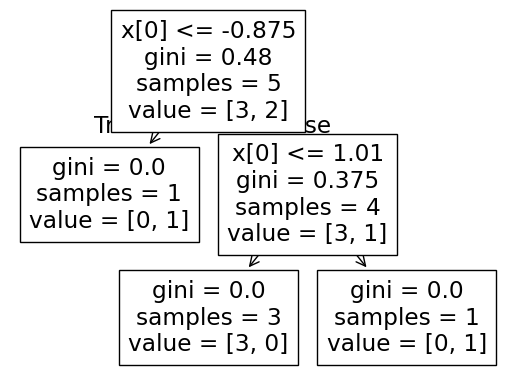

In [17]:
from sklearn.tree import plot_tree
plot_tree(clf)

In [18]:
clf.feature_importances_

array([1., 0.])

In [19]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=2)
rf.fit(X,y)

RandomForestClassifier(n_estimators=2)

In [20]:
rf.feature_importances_

array([1., 0.])

In [21]:
print(rf.estimators_[0].feature_importances_)
print(rf.estimators_[1].feature_importances_)

print((1 + 0.555)/2)


[1. 0.]
[1. 0.]
0.7775000000000001


In [28]:
X,y = make_classification(n_samples=15, n_classes=2,
                               n_features=2, n_informative=2, n_redundant=0,
                               random_state=0)


In [29]:
from sklearn.tree import DecisionTreeClassifier

In [30]:
clf = DecisionTreeClassifier()

In [32]:
clf.fit(X,y)

DecisionTreeClassifier()

[Text(0.3333333333333333, 0.875, 'x[1] <= -0.383\ngini = 0.498\nsamples = 15\nvalue = [8, 7]'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[0] <= 0.878\ngini = 0.346\nsamples = 9\nvalue = [2, 7]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.6666666666666666, 0.375, 'x[1] <= -0.278\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8333333333333334, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]')]

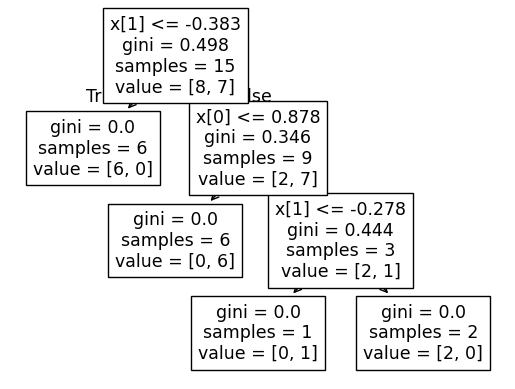

In [33]:
from sklearn.tree import plot_tree
plot_tree(clf)

In [34]:
clf.feature_importances_

array([0.23809524, 0.76190476])